# Introduction to Quantum Computing & Qiskit 
Welcome to Qiskit Fall Fest 2026! In this introductory notebook, we will explore the absolute fundamentals of quantum computing. You will learn how to build, visualize, and simulate your very first quantum circuits using Qiskit.
## 🛠️ Step 1: Setting Up the Environment
Before we write quantum code, we need to import the essential tools from Qiskit. We will use the modern qiskit library along with `qiskit-aer` (for simulating quantum circuits on your laptop) and `qiskit.visualization` (to see what our circuits look like).
Run the cell below to import the required libraries.

In [1]:
# Install the packages if you are running locally (uncomment the line below if needed)
# %pip install qiskit qiskit-aer matplotlib

import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

print(f"Qiskit version successfully loaded!")
print(qiskit.__version__)

Qiskit version successfully loaded!
2.5.2


## 🧠 Step 2: The Core Concept — Qubits vs. Bits
• Classical Bit: Can only exist in one of two definite states: 0 or 1.

• Quantum Bit (Qubit): Can exist in a superposition of both states simultaneously: $\alpha\vert{}0\rangle + \beta\vert{}1\rangle$.

When we observe (measure) a qubit in superposition, it collapses randomly into either 0 or 1, depending on the probabilities defined by α and β.

## 🏗️ Step 3: Creating Your First Quantum Circuit
Let's build a simple quantum circuit. We will start with a single qubit, apply a **NOT gate** (known as an **X Gate** in quantum computing) to flip its state from 0 to 1, and then measure it.

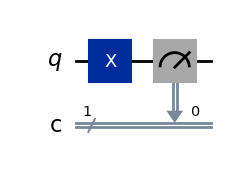

In [2]:
# 1. Initialize a Quantum Circuit with 1 quantum qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# 2. Apply an X gate (NOT gate) to qubit 0
qc.x(0)

# 3. Measure qubit 0 and store the result in classical bit 0
qc.measure(0, 0)

# 4. Draw the circuit visually using matplotlib
qc.draw('mpl')


## 🔬 Step 4: Simulating the Circuit
Because we don't want to wait in a queue for real quantum hardware during a quick test, we will use `AerSimulator` to simulate an ideal quantum computer right on the cloud or your computer. We will run the circuit **1024 times (shots)** to see the probability distribution.

Measurement results: {'1': 1024}


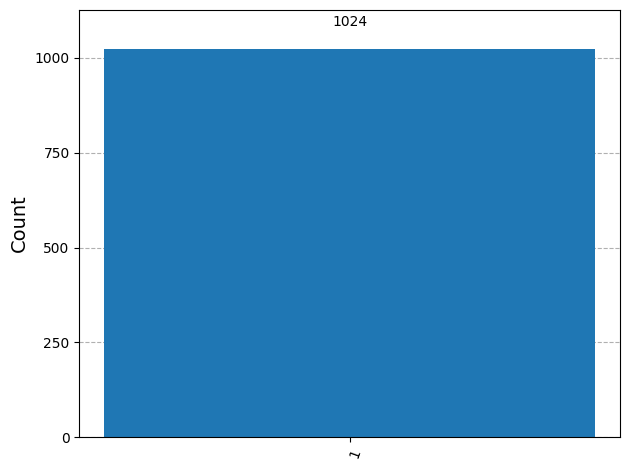

In [3]:
# 1. Initialize the local quantum simulator
simulator = AerSimulator()

# 2. Run the circuit on the simulator
job = simulator.run(qc, shots=1024)

# 3. Grab the measurement counts
counts = job.result().get_counts()
print("Measurement results:", counts)

# 4. Plot the histogram of the results
plot_histogram(counts)


*(Expected Output: A 100% chance of getting the state 1 because the X gate flipped it from 0).*

## 🚀 Step 5: Entering Superposition (The Hadarmard Gate)
Now let's do something a classical computer cannot do. We will use the **Hadamard (H) Gate** to put a qubit into an equal superposition of 0 and 1. This means it will have a 50% chance of collapsing into 0 and a 50% chance of collapsing into 1 upon measurement.

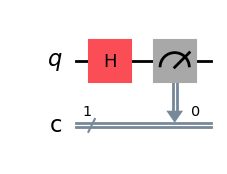

In [4]:
# Create a new circuit
superposition_circuit = QuantumCircuit(1, 1)

# Apply the H gate to qubit 0
superposition_circuit.h(0)

# Measure the qubit
superposition_circuit.measure(0, 0)

# Draw the circuit
superposition_circuit.draw('mpl')


Let's run this new circuit to see the randomness in action:

Superposition results: {'0': 507, '1': 517}


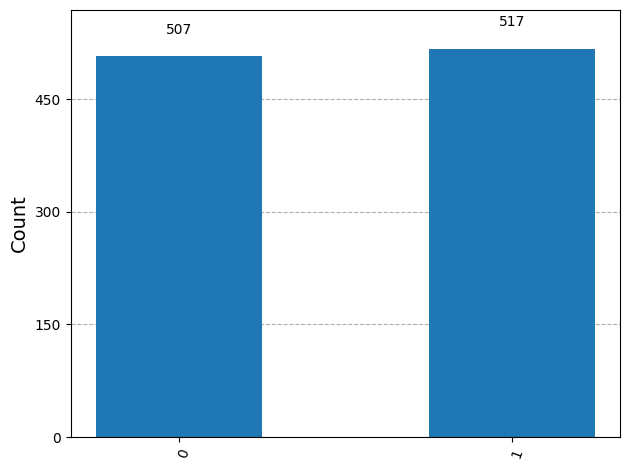

In [5]:
# Run the simulation
job = simulator.run(superposition_circuit, shots=1024)
superposition_counts = job.result().get_counts()

print("Superposition results:", superposition_counts)
plot_histogram(superposition_counts)


*(Expected Output: A roughly 50/50 split between 0 and 1).*

## 🔗 Step 6: Creating Quantum Entanglement (The Bell State)
Einstein called it "spooky action at a distance." **Entanglement** links two or more qubits together so that the state of one instantly dictates the state of the other, no matter how far apart they are.
We create a Bell State using two components:
1. An H Gate on Qubit 0 (putting it in superposition).
2. A Controlled-NOT (CNOT) Gate using Qubit 0 as the control and Qubit 1 as the target.


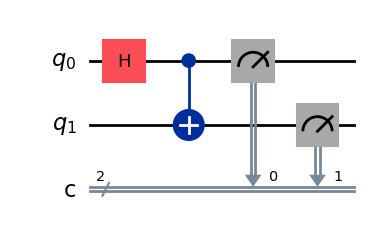

In [6]:
# Create a circuit with 2 qubits and 2 classical bits
bell_circuit = QuantumCircuit(2, 2)

# Step 1: Put Qubit 0 in superposition
bell_circuit.h(0)

# Step 2: Entangle Qubit 0 and Qubit 1 using a CNOT gate
bell_circuit.cx(0, 1)

# Step 3: Measure both qubits
bell_circuit.measure([0, 1], [0, 1])

# Draw the entangled circuit
bell_circuit.draw('mpl')


Let's simulate our entangled qubits:

Entanglement results: {'11': 525, '00': 499}


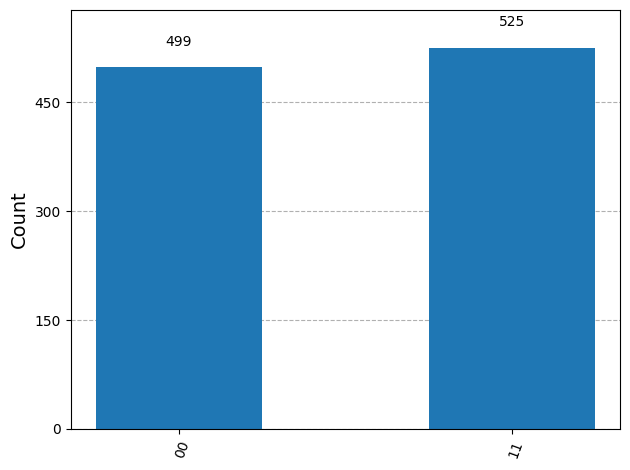

In [7]:
# Run the simulation
job = simulator.run(bell_circuit, shots=1024)
bell_counts = job.result().get_counts()

print("Entanglement results:", bell_counts)
plot_histogram(bell_counts)


## 📊 What just happened?
Notice that you will only see the outcomes 00 and 11! You will almost never see 01 or 10. This proves the qubits are completely entangled: if Qubit 0 randomly collapses into 0, Qubit 1 is instantly forced to become 0 as well.

## 🏆 Your First Challenge!
Try to modify the Bell State code above in a new cell to create a circuit where the results are always opposites (01 or 10), but never the same.
(Hint: Try applying an X gate to one of the qubits right at the very beginning before you do anything else!)

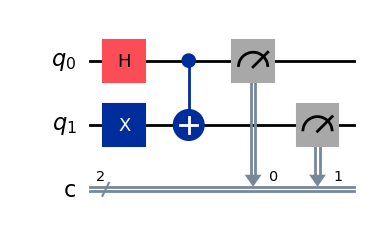

In [8]:
# Create a circuit with 2 qubits and 2 classical bits
bell_circuit = QuantumCircuit(2, 2)

# Step 1: Put Qubit 0 in superposition
bell_circuit.x(1)
bell_circuit.h(0)

# Step 2: Entangle Qubit 0 and Qubit 1 using a CNOT gate
bell_circuit.cx(0, 1)

# Step 3: Measure both qubits
bell_circuit.measure([0, 1], [0, 1])

# Draw the entangled circuit
bell_circuit.draw('mpl')


Entanglement results: {'01': 518, '10': 506}


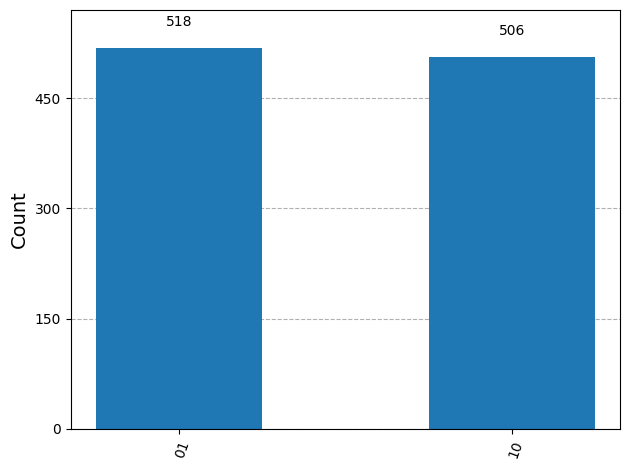

In [9]:
# Run the simulation
job = simulator.run(bell_circuit, shots=1024)
bell_counts = job.result().get_counts()

print("Entanglement results:", bell_counts)
plot_histogram(bell_counts)
